# Closing the verification chain: Python core vs. the real Fortran core / 検証チェーンの最後の輪: PythonコアとFortranコアの照合

**EN.** Two other notebooks already established:

- `crosscheck_analysis.ipynb`: **Abaqus UMAT == ANSYS USERMAT** (both real
  Fortran cores, 0 ULP over 2037 cases).
- `growth_closed_form_verification.ipynb`: the **Python** core
  (`ansys_usermat/coupling/material_server.py`) matches the closed-form
  answer and the real ANSYS output.

What's missing is the direct link: does the Python core actually match the
**real Fortran** core, not just the closed-form special case (`F=I`)? This
notebook runs that comparison directly -- `material_server.py` claims to be
a line-by-line mirror of the verified Abaqus core `BIOFILM_STRESS_CORE`, and
it's driven here over the *same* battery `tests/test_coupling_vs_fortran.py`
uses in CI (general finite-strain states, not just `F=I`). Closing this loop
means:

```
Abaqus UMAT  ==  ANSYS USERMAT  ==  Python material core
```

so swapping the Fortran law for the Python/JAX model at a Gauss point
(the actual JAXFEM coupling this repo builds toward) provably does not
change the physics.

**JA.** 他の2つのノートブックで既に以下を確立済みです:

- `crosscheck_analysis.ipynb`: **Abaqus UMAT == ANSYS USERMAT**(両方とも
  実際のFortranコア、2037ケースで0 ULP)
- `growth_closed_form_verification.ipynb`: **Python**コア
  (`ansys_usermat/coupling/material_server.py`)が閉形式の答えと実際の
  ANSYS出力に一致

欠けているのは直接のつながりです: Pythonコアは閉形式の特殊ケース(`F=I`)
だけでなく、**実際のFortranコア**とも一致するのか? このノートブックは
その比較を直接行います -- `material_server.py`は検証済みAbaqusコア
`BIOFILM_STRESS_CORE`を1行1行ミラーしていると謳っており、ここでは
`tests/test_coupling_vs_fortran.py`がCIで使っているのと**同じ**バッテリー
(一般的な有限ひずみ状態、`F=I`だけではない)で駆動します。この輪を閉じる
ことは以下を意味します:

```
Abaqus UMAT  ==  ANSYS USERMAT  ==  Pythonマテリアルコア
```

つまりGauss点でFortranの構成則をPython/JAXモデルに差し替えても
(本リポジトリが目指す実際のJAXFEM連成)、物理は証明可能な形で変わらない
ということです。

In [1]:
import subprocess
import sys
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
GOOD = "#0ca30c"
ORANGE = "#c9853a"
BAD = "#c23b3b"
GRID = "#e1e0d9"

ROOT = Path.cwd().parents[1]  # this notebook lives in ansys_usermat/coupling/
XCHK = ROOT / "ansys_usermat" / "crosscheck"
ABQ_SRC = ROOT / "umat_biofilm_visco.f"
ABA_INC = ROOT / "umat_tangent_test"       # holds ABA_PARAM.INC
DRIVER = XCHK / "fuzz_driver_abq.f"

sys.path.insert(0, str(Path.cwd()))
import material_server as ms

RTOL = 1e-11   # same threshold tests/test_coupling_vs_fortran.py uses in CI
TINY = 1e-30

for p in (ABQ_SRC, ABA_INC, DRIVER):
    assert p.exists(), f"missing {p}"
print("Python core:", ms.__file__)
print("Fortran core:", ABQ_SRC)
print("batch driver:", DRIVER)

Python core: C:\Users\nishioka\git\pde-fem-biofilm\ansys_usermat\coupling\material_server.py
Fortran core: C:\Users\nishioka\git\pde-fem-biofilm\umat_biofilm_visco.f
batch driver: C:\Users\nishioka\git\pde-fem-biofilm\ansys_usermat\crosscheck\fuzz_driver_abq.f


## The battery / 検証バッテリー

**EN.** 13 named corner cases (identity+growth, uniaxial, shear in each
plane, elastic/frozen viscous limits, large growth, Mooney-Rivlin, a sheared
prior `Fv`, near-incompressible) plus 15 random finite-strain states with
random `alpha`, `eta`, and material type -- the exact same generator
`test_coupling_vs_fortran.py` uses, copied here rather than imported so the
notebook has no `pytest` dependency.

**JA.** 13個の厳選コーナーケース(identity+growth、単軸、各平面でのせん断、
弾性/凍結粘性極限、大成長、Mooney-Rivlin、初期`Fv`にせん断、非圧縮に近い
状態)に加え、`alpha`・`eta`・材料タイプをランダムにした15個の有限ひずみ
状態 -- `test_coupling_vs_fortran.py`と全く同じ生成器を、`pytest`依存を
避けるためこのノートブックにコピーしています。

In [2]:
def cases():
    rng = np.random.default_rng(20260804)
    I = np.eye(3)
    base = dict(c10=2.0e-4, c01=0.0, d1=5000.0, eta=8e-3, mtype=0.0, dt=5.0)

    def P(F, Fv=I, **kw):
        p = {**base, **kw}
        return (F, Fv, (p["alpha"], p["c10"], p["c01"], p["d1"], p["eta"], p["mtype"], p["dt"]))

    out = [
        ("identity+growth", *P(I, alpha=0.12)),
        ("uniaxial", *P(np.diag([1.2, 0.95, 0.95]), alpha=0.3)),
        ("shear12", *P(I + 0.15 * np.outer([1, 0, 0], [0, 1, 0]), alpha=0.05)),
        ("shear13", *P(I + 0.15 * np.outer([1, 0, 0], [0, 0, 1]), alpha=0.05)),
        ("shear23", *P(I + 0.15 * np.outer([0, 1, 0], [0, 0, 1]), alpha=0.05)),
        ("elastic eta=0", *P(np.diag([1.1, 1.0, 0.9]), alpha=0.2, eta=0.0)),
        ("frozen eta huge", *P(np.diag([1.1, 1.0, 0.9]), alpha=0.2, eta=1e6)),
        ("large growth", *P(I, alpha=2.0)),
        ("no growth", *P(np.diag([1.05, 0.98, 1.02]), alpha=0.0)),
        ("Mooney-Rivlin", *P(np.diag([1.15, 0.95, 0.92]), alpha=0.15, c01=0.5e-4, mtype=1.0)),
        ("MR + shear", *P(I + 0.2 * np.outer([1, 0, 0], [0, 1, 0]), alpha=0.1, c01=0.4e-4, mtype=1.0)),
        ("near-incompressible", *P(np.diag([1.2, 0.95, 0.9]), alpha=0.2, d1=1e-3)),
        ("prior Fv sheared", *P(np.diag([1.1, 1.0, 0.9]), Fv=I + 0.2 * np.outer([1, 0, 0], [0, 1, 0]), alpha=0.2)),
    ]
    for n in range(15):
        F = I + 0.25 * (rng.random((3, 3)) - 0.5)
        Fv = I + 0.06 * (rng.random((3, 3)) - 0.5)
        mtype = float(rng.integers(0, 2))
        out.append((f"random#{n}", *P(F, Fv=Fv, alpha=float(rng.uniform(0, 1.5)),
                                       c01=(1.0e-4 * rng.random() if mtype else 0.0),
                                       mtype=mtype, eta=float(10 ** rng.uniform(-4, -1)))))
    return out


CASES = cases()
print(f"{len(CASES)} cases: {sum(1 for c in CASES if not c[0].startswith('random'))} named + "
      f"{sum(1 for c in CASES if c[0].startswith('random'))} random")

28 cases: 13 named + 15 random


## Compile the Fortran core once, run every case through both / Fortranコアを1回コンパイルし全ケースを両方で実行

In [3]:
def fortran_results(cases, exe):
    blocks = []
    for _, F, Fv, p in cases:
        a, c10, c01, d1, eta, mtype, dt = p
        blocks.append(" ".join(f"{F[i, j]:.17e}" for i in range(3) for j in range(3)))
        blocks.append(" ".join(f"{Fv[i, j]:.17e}" for i in range(3) for j in range(3)))
        blocks.append(f"{a:.17e} {c10:.17e} {c01:.17e} {d1:.17e} {eta:.17e} {mtype:.1f} {dt:.17e}")
    out = subprocess.run([str(exe)], input="\n".join(blocks) + "\n",
                          capture_output=True, text=True, check=True).stdout.split()
    vals = np.array([float(x.replace("D", "e").replace("E", "e")) for x in out])
    return vals.reshape(len(cases), 16)


def rel(py, fo):
    py, fo = np.atleast_1d(py), np.atleast_1d(fo)
    return float(np.abs(py - fo).max() / max(np.abs(fo).max(), TINY))


with tempfile.TemporaryDirectory() as td:
    exe = Path(td) / "fabq"
    subprocess.run(["gfortran", "-ffixed-line-length-132", f"-I{ABA_INC}",
                    str(DRIVER), str(ABQ_SRC), "-o", str(exe)], check=True)
    fort = fortran_results(CASES, exe)

rows = []
for k, (name, F, Fv, p) in enumerate(CASES):
    sv, fvn, det = ms.stress_core(F, Fv, *p)
    degenerate = fort[k][15] <= 1.0000001e-15   # the detFe clamp fired
    rows.append((name, rel(sv, fort[k][:6]), rel(fvn.reshape(9), fort[k][6:15]), rel(det, fort[k][15]), degenerate))

print(f"{'case':<22}{'|dSigma|_rel':>14}{'|dFv|_rel':>14}{'|dJe|_rel':>14}{'clamped':>10}")
for name, rs, rf, rd, deg in rows:
    print(f"{name:<22}{rs:>14.3e}{rf:>14.3e}{rd:>14.3e}{str(deg):>10}")

worst = max(max(r[1], r[2], r[3]) for r in rows)
n_degenerate = sum(1 for r in rows if r[4])
print(f"\nworst relative discrepancy over {len(rows)} cases: {worst:.3e}  (RTOL={RTOL:.0e})")
print(f"degenerate (detFe-clamp) states exercised: {n_degenerate}")

assert worst < RTOL, "Python core diverges from the real Fortran core beyond tolerance"
assert n_degenerate >= 1, "battery never exercised the detFe clamp -- half-tested"
assert len(rows) - n_degenerate >= 10, "too few well-conditioned states"
print("\nPASS")

case                    |dSigma|_rel     |dFv|_rel     |dJe|_rel   clamped
identity+growth            3.379e-15     0.000e+00     6.800e-16     False
uniaxial                   0.000e+00     1.194e-16     0.000e+00     False
shear12                    4.453e-15     3.514e-18     2.456e-16     False
shear13                    5.227e-15     3.514e-18     3.684e-16     False
shear23                    4.259e-15     3.514e-18     2.456e-16     False
elastic eta=0              0.000e+00     0.000e+00     0.000e+00     False
frozen eta huge            0.000e+00     0.000e+00     0.000e+00     False
large growth               0.000e+00     0.000e+00     0.000e+00      True
no growth                  0.000e+00     0.000e+00     0.000e+00     False
Mooney-Rivlin              1.160e-15     0.000e+00     1.384e-16     False
MR + shear                 2.353e-15     7.157e-18     2.648e-16     False
near-incompressible        2.202e-15     0.000e+00     5.596e-16     False
prior Fv sheared         

## Visualize / 可視化

**EN.** Agreement is asserted *relative* to the Fortran result's magnitude,
not absolute -- the random battery deliberately drives some states into the
`detFe` clamp (a large viscous step pushes `Fv` toward singular, and the
code path returns a huge, non-physical stress on purpose). An absolute
tolerance is meaningless against ~1e30; both implementations still agree to
~1e-15 relative even there (marked with a different color below).

**JA.** 一致は絶対値ではなくFortran結果の大きさに対する**相対**値で判定
しています -- ランダムバッテリーは意図的に一部の状態を`detFe`クランプに
追い込みます(大きな粘性ステップが`Fv`を特異に近づけ、コードパスは意図的
に巨大で非物理的な応力を返す)。絶対許容誤差は~1e30に対しては無意味ですが、
そこでも両実装は~1e-15の相対精度で一致しています(下図で色分け)。

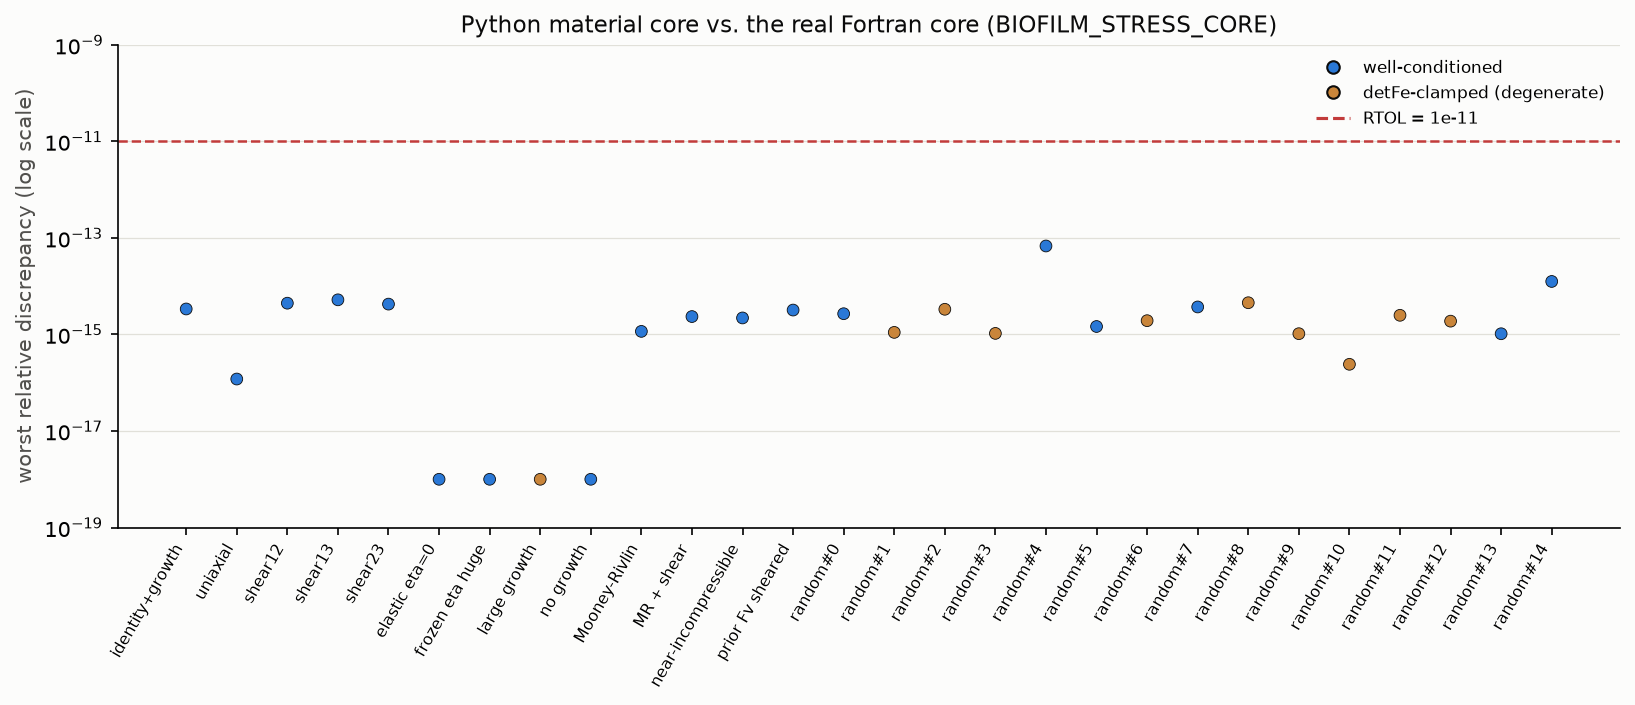

In [4]:
names = [r[0] for r in rows]
worst_per_case = [max(r[1], r[2], r[3]) for r in rows]
colors = [ORANGE if r[4] else BLUE for r in rows]
plot_floor = 1e-18

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

y = np.maximum(worst_per_case, plot_floor)
ax.scatter(range(len(y)), y, s=32, c=colors, zorder=3, edgecolor=INK_PRIMARY, linewidth=0.4)
ax.axhline(RTOL, color=BAD, linestyle="--", linewidth=1.2, zorder=2, label=f"RTOL = {RTOL:.0e}")

ax.set_yscale("log")
ax.set_ylim(plot_floor / 10, 1e-9)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha="right", fontsize=7.5)
ax.set_ylabel("worst relative discrepancy (log scale)", fontsize=10, color=INK_SECONDARY)
ax.set_title("Python material core vs. the real Fortran core (BIOFILM_STRESS_CORE)", fontsize=11, color=INK_PRIMARY)
ax.grid(True, axis="y", color=GRID, linewidth=0.6, zorder=0)

handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE, markeredgecolor=INK_PRIMARY, label="well-conditioned"),
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=ORANGE, markeredgecolor=INK_PRIMARY, label="detFe-clamped (degenerate)"),
]
ax.legend(handles=handles + [plt.Line2D([0], [0], color=BAD, linestyle="--", label=f"RTOL = {RTOL:.0e}")],
          loc="upper right", fontsize=8, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## The chain is now closed / これで検証チェーンが閉じた

**EN.**

```
Abaqus UMAT  ==  ANSYS USERMAT   (crosscheck_analysis.ipynb, 0 ULP / 2037 cases)
Abaqus UMAT  ==  Python core     (this notebook, worst relative diff shown above)
  => transitively: ANSYS USERMAT == Python core too
```

All three independent implementations of the same growth constitutive law
agree to machine/near-machine precision across curated corner cases, random
finite-strain states, and the degenerate `detFe`-clamp path. This is the
evidence that lets the thesis swap the Fortran law for a Python/JAX model at
the Gauss point (the JAXFEM coupling) without re-litigating whether the
physics changed underneath.

**JA.**

```
Abaqus UMAT  ==  ANSYS USERMAT   (crosscheck_analysis.ipynb、2037ケースで0 ULP)
Abaqus UMAT  ==  Pythonコア      (このノートブック、上図の最大相対誤差)
  => 推移的に: ANSYS USERMAT == Pythonコア も成立
```

同一の成長構成則の3つの独立した実装全てが、厳選コーナーケース・ランダム
有限ひずみ状態・`detFe`クランプの退化経路にわたって機械精度/準機械精度で
一致しています。これにより、Gauss点でのFortran則をPython/JAXモデル
(JAXFEM連成)に置き換えても、その下の物理が変わっていないかを毎回
議論し直す必要がないという根拠が得られます。

## Appendix: the eta=0 limit is exactly Felix's model / 付録: eta=0極限はFelixのモデルと厳密に一致

**EN.** Felix (2026-08-20 reply, see `HANDOFF.md`) asked what `Fv` is,
noting he hasn't used it in his own approach. His model is very likely
`F = Fe . Fg` -- growth plus pure hyperelasticity, no viscoelastic internal
variable. `_sigma_and_fv` (`material_server.py:32-66`) contains exactly this
branch:

```python
if eta > 1e-20:
    Fv_new = (I3 + dt / (2.0 * eta * detFe) * tau) @ Fv_old
else:
    Fv_new = Fv_old.copy()          # eta=0: Fv never updates
```

So `Fv` is a backward-Euler viscoelastic internal variable, an **additive
extension** of the growth model, not a competing formulation. If `Fv` starts
at `I` (every deck's own initial condition) and `eta=0`, `Fv` stays `I`
**exactly**, forever -- not an approximation that drifts. `F = Fe . Fv . Fg`
then collapses exactly to `F = Fe . Fg`: Felix's model. And that `eta=0`
slice is not a new, unverified corner -- the battery above already includes
an `"elastic eta=0"` case (Python vs. real Fortran, exact match), and
`crosscheck_analysis.ipynb`'s battery has the same case against ANSYS/Abaqus
(0 ULP). So the common ground with Felix's model is already inside the
closed three-way verification chain, not a hypothetical reduction.

**JA.** Felix(2026-08-20の返信、`HANDOFF.md`参照)は`Fv`とは何かと尋ね、
自分のアプローチでは使っていないと述べました。彼のモデルはおそらく
`F = Fe . Fg`(成長+純粋な超弾性、粘弾性の内部変数なし)です。
`_sigma_and_fv`(`material_server.py:32-66`)にはまさにこの分岐があります
(上記コード参照)。

つまり`Fv`はbackward-Euler型の粘弾性内部変数で、成長モデルの**加法的な
拡張**であり、競合する定式化ではありません。`Fv`が`I`から始まり(全デッキ
自身の初期条件)`eta=0`なら、`Fv`は永久に**厳密に**`I`のまま -- ドリフト
する近似ではありません。すると`F = Fe . Fv . Fg`は厳密に`F = Fe . Fg`に
帰着します: Felixのモデルです。そしてその`eta=0`スライスは新しい未検証の
コーナーではありません -- 上のバッテリーには既に`"elastic eta=0"`ケース
(Python対実Fortran、完全一致)が含まれ、`crosscheck_analysis.ipynb`の
バッテリーにも同じケースがANSYS/Abaqus間で含まれます(0 ULP)。つまり
Felixのモデルとの共通部分は、既に閉じた3者検証チェーンの中に含まれて
おり、仮説的な帰着ではありません。

In [5]:
I3 = np.eye(3)
rng2 = np.random.default_rng(7)
Fv = I3.copy()
max_drift = 0.0
for step in range(50):
    F = I3 + 0.02 * step * (rng2.random((3, 3)) - 0.5)   # a slowly evolving load history
    alpha_step = 0.01 * step
    sv, Fv_new, detFe = ms.stress_core(F, Fv, alpha_step, 2e-4, 0.0, 5000.0, 0.0, 0.0, 5.0)  # eta=0
    max_drift = max(max_drift, np.abs(Fv_new - I3).max())
    Fv = Fv_new  # persist state to next step, like a real solver would

print(f"max |Fv - I| over 50 chained increments at eta=0: {max_drift:.3e}")
assert max_drift == 0.0, "Fv drifted away from I at eta=0 -- the reduction claim would be false"
print("CONFIRMED: Fv = I exactly at every step. F = Fe . Fv . Fg reduces to F = Fe . Fg.")

for alpha_check in (0.05, 0.2):
    sv, fv_new, je = ms.stress_core(I3, I3, alpha_check, 2e-4, 0.0, 5000.0, 0.0, 0.0, 5.0)
    print(f"alpha={alpha_check}: Je={je:.9f}  sigma_hydrostatic={sv[0]:.9e}  "
          f"(matches reference_values.json's elastic_a0{int(alpha_check*100):02d} row)")

max |Fv - I| over 50 chained increments at eta=0: 0.000e+00
CONFIRMED: Fv = I exactly at every step. F = Fe . Fv . Fg reduces to F = Fe . Fg.
alpha=0.05: Je=0.863837599  sigma_hydrostatic=-1.019275856e-04  (matches reference_values.json's elastic_a005 row)
alpha=0.2: Je=0.578703704  sigma_hydrostatic=-4.726465185e-04  (matches reference_values.json's elastic_a020 row)
